In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
!pip install --upgrade openpyxl

Defaulting to user installation because normal site-packages is not writeable


In [3]:
df = pd.read_excel("Downloads/random_forest_dataset.xlsx")
df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
0,Sl No,USN,Name,Title,P1,C1,P2,C2,P3,C3,R1,T1,P3T,Total,Grade
1,1,1RV21MC001,ABHISHEK M,Generative AI Prompt Pipeline,78,15.6,85,34,93,18.6,13,4,35.6,85.2,A
2,2,1RV21MC002,ABHISHEK RANJANAGOUDA G,Android based Smart Vehicle Parking System usi...,84,16.8,82,32.8,77,15.4,15,5,35.4,85,A
3,3,1RV21MC003,ADARSH V MORYE,Sentimental Analysis for product ratings,84,16.8,82,32.8,88,17.6,13,1,31.6,81.2,A
4,4,1RV21MC004,AISHWARYA K KAMBLE,Analysis and Deployment of an efficient Deep L...,88,17.6,85,34,96,19.2,13,4,36.2,87.8,A


In [4]:
df = pd.read_excel("Downloads/random_forest_dataset.xlsx", header=1)
df.head()

,Sl No,USN,Name,Title,P1,C1,P2,C2,P3,C3,R1,T1,P3T,Total,Grade
0,1,1RV21MC001,ABHISHEK M,Generative AI Prompt Pipeline,78,15.6,85.0,34.0,93,18.6,13.0,4.0,35.6,85.2,A
1,2,1RV21MC002,ABHISHEK RANJANAGOUDA G,Android based Smart Vehicle Parking System usi...,84,16.8,82.0,32.8,77,15.4,15.0,5.0,35.4,85.0,A
2,3,1RV21MC003,ADARSH V MORYE,Sentimental Analysis for product ratings,84,16.8,82.0,32.8,88,17.6,13.0,1.0,31.6,81.2,A
3,4,1RV21MC004,AISHWARYA K KAMBLE,Analysis and Deployment of an efficient Deep L...,88,17.6,85.0,34.0,96,19.2,13.0,4.0,36.2,87.8,A
4,5,1RV21MC005,AISHWARYA NAGARAJ BABALESHWAR,Development of Deep Learning Model for Varied ...,84,16.8,82.0,32.8,77,15.4,15.0,5.0,35.4,85.0,A


In [5]:
df.isnull().sum()

Sl No     0
USN       0
Name      0
Title     1
P1        0
C1        0
P2        0
C2        0
P3        0
C3        0
R1        8
T1        8
P3T       0
Total     0
Grade     8
dtype: int64

In [6]:
df.dropna(inplace=True)

x = df.drop(['Sl No ',"USN ","Name ","Title ","Grade"],axis=1)
y = df.Grade

In [7]:
x.head()

,P1,C1,P2,C2,P3,C3,R1,T1,P3T,Total
0,78,15.6,85.0,34.0,93,18.6,13.0,4.0,35.6,85.2
1,84,16.8,82.0,32.8,77,15.4,15.0,5.0,35.4,85.0
2,84,16.8,82.0,32.8,88,17.6,13.0,1.0,31.6,81.2
3,88,17.6,85.0,34.0,96,19.2,13.0,4.0,36.2,87.8
4,84,16.8,82.0,32.8,77,15.4,15.0,5.0,35.4,85.0


In [8]:
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()
y=label_encoder.fit_transform(df['Grade'])

In [9]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)
rf = RandomForestClassifier(random_state=42)
rf.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Total     0.306664
C2        0.129852
P3T       0.128892
P2        0.124975
C1        0.093364
P1        0.084462
P3        0.035479
C3        0.034869
R1        0.032332
T1        0.029110
dtype: float64


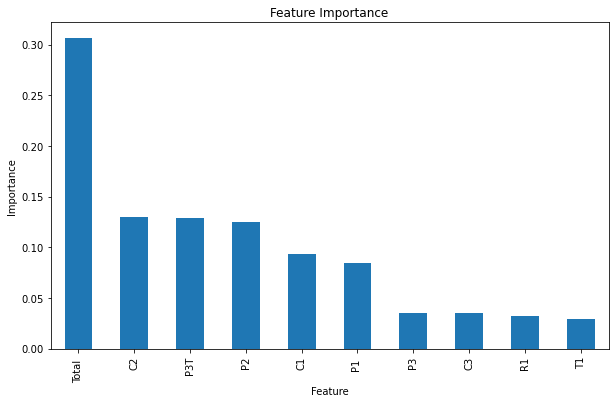

In [10]:
feature_importances = pd.Series(rf.feature_importances_, index=x.columns).sort_values(ascending=False)
print(feature_importances)
plt.figure(figsize=(10, 6))
feature_importances.plot(kind='bar')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Feature Importance')
plt.show()

In [11]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200, 300], 
    'max_depth': [10,25, 35],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5] 
}

grid_search = GridSearchCV(estimator=rf, param_grid = param_grid, cv=5, n_jobs=-1,verbose=1)

grid_search.fit(x_train,y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


/home/dsbatch2/.local/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [10, 25, ...], 'min_samples_leaf': [1, 3, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [12]:
best_params = grid_search.best_params_
best_params

{'max_depth': 10,
 'min_samples_leaf': 3,
 'min_samples_split': 10,
 'n_estimators': 200}

In [13]:
best_rf = RandomForestClassifier(random_state=42,**best_params)
best_rf.fit(x_train,y_train)
y_pred = best_rf.predict(x_test)

In [14]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"🔹 Accuracy: {accuracy:.4f}")
print(f"🔹 Precision: {precision:.4f}")
print(f"🔹 Recall: {recall:.4f}")
print(f"🔹 F1 Score: {f1:.4f}")


🔹 Accuracy: 0.8182
🔹 Precision: 0.8347
🔹 Recall: 0.8182
🔹 F1 Score: 0.8031


/home/dsbatch2/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


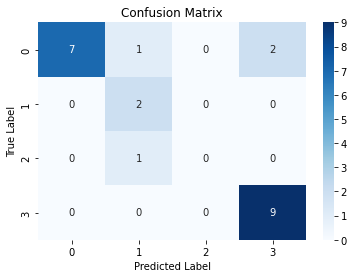

In [15]:
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

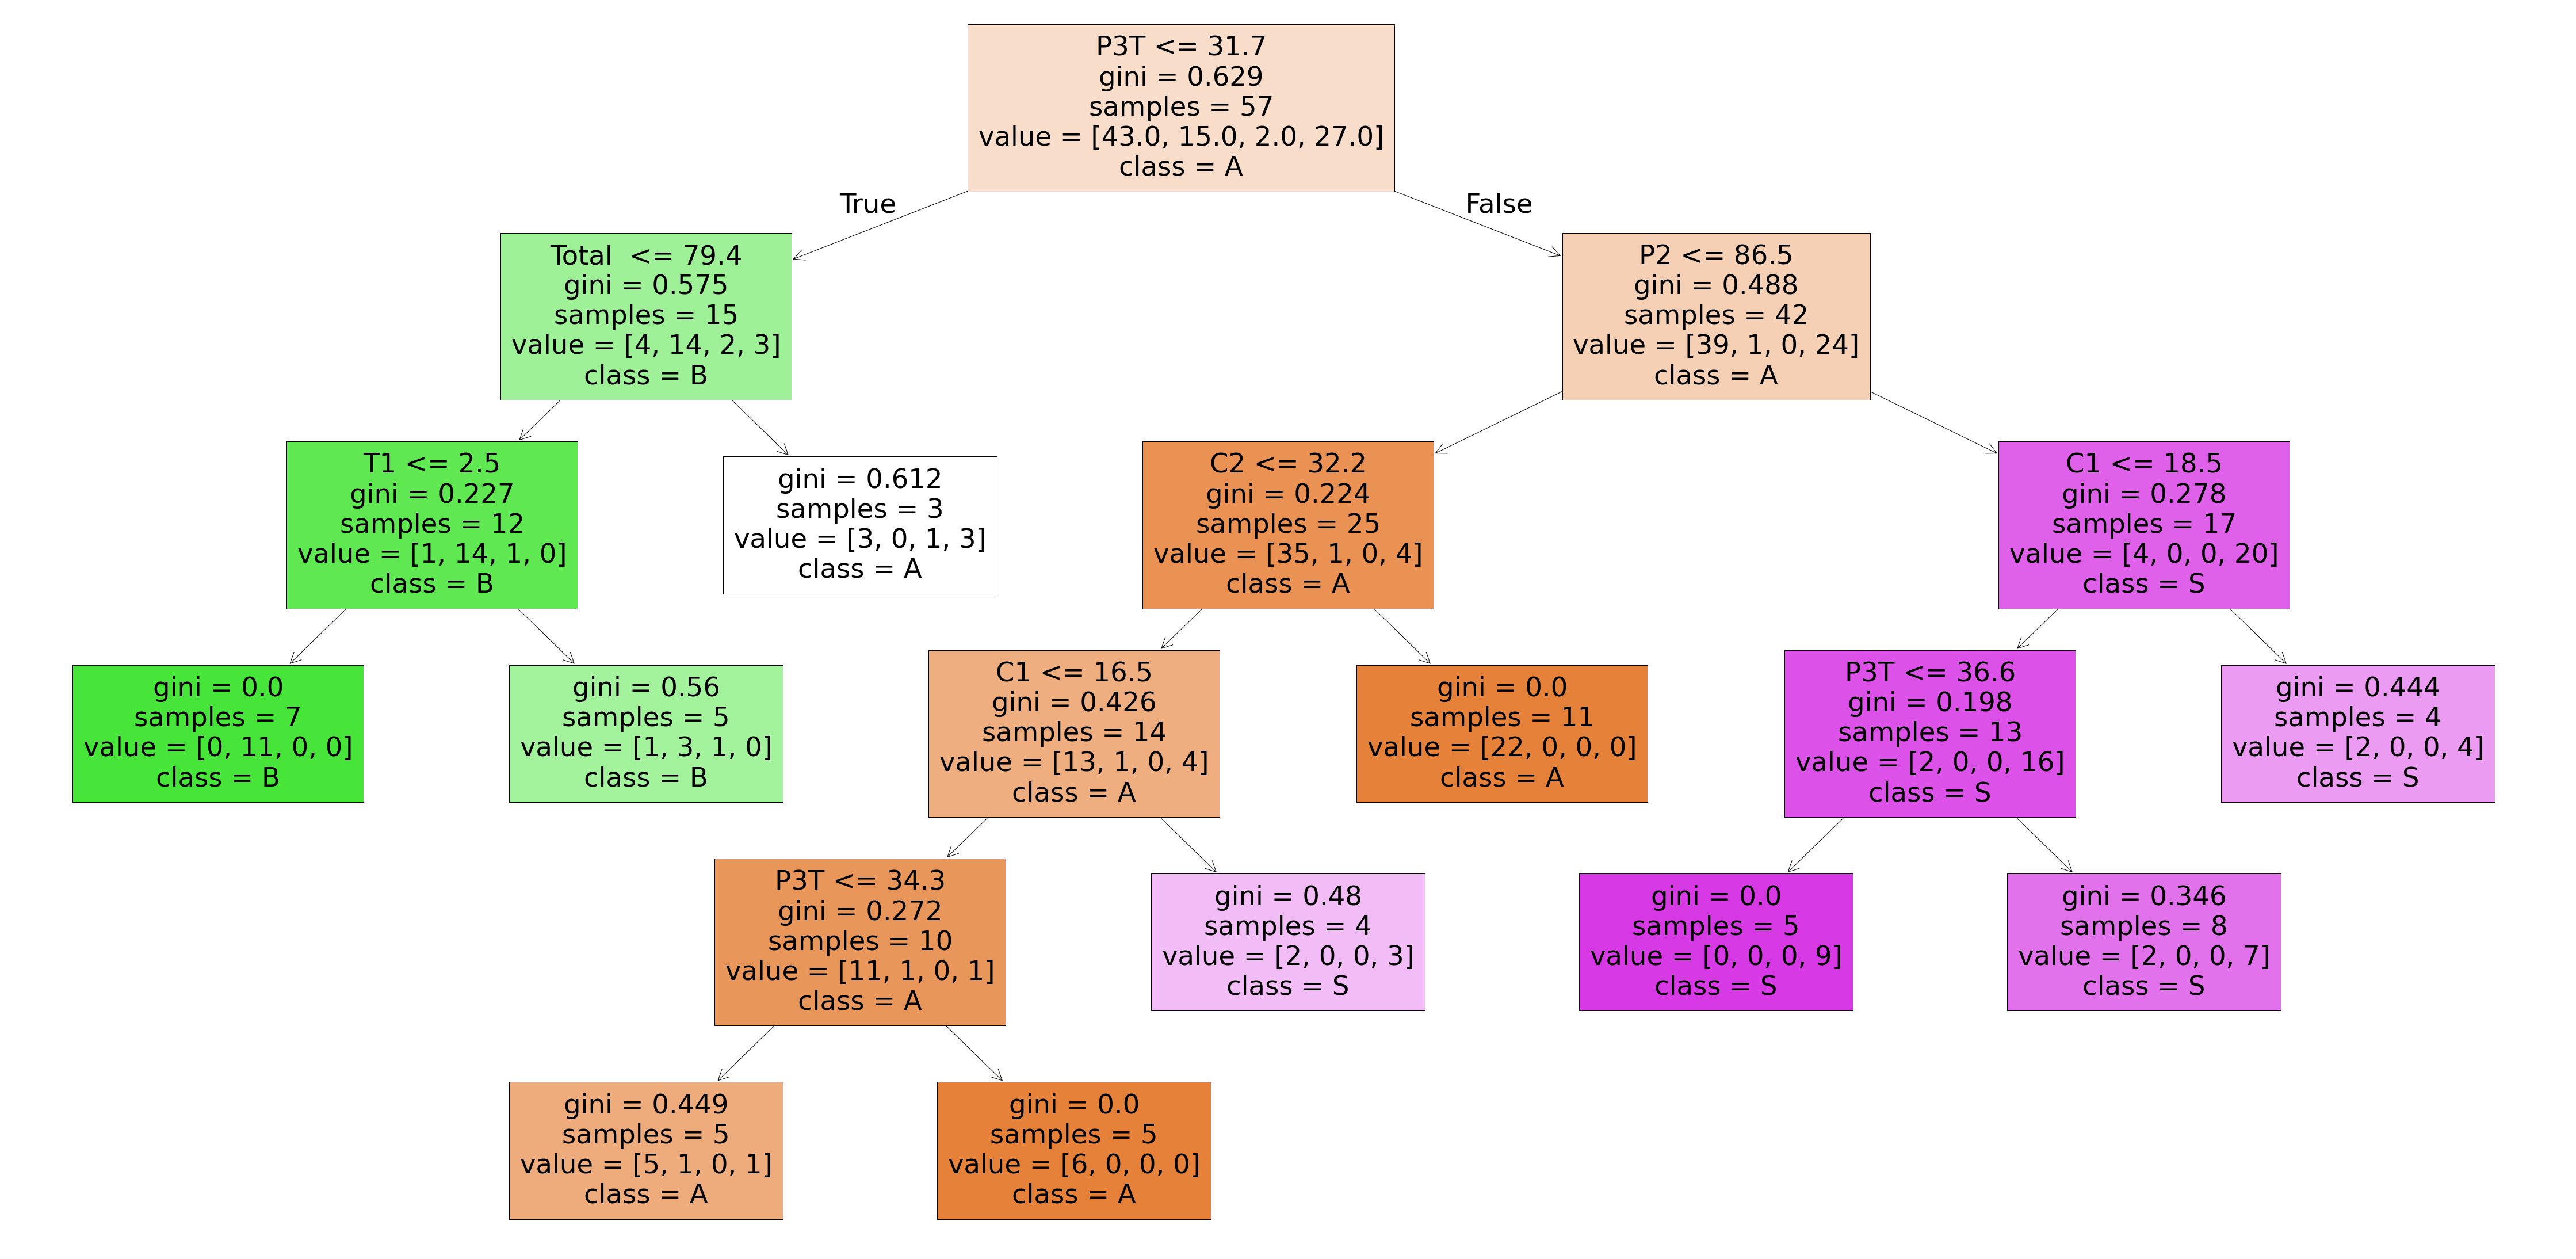

In [16]:
from sklearn.tree import plot_tree
plt.figure(figsize=(80,40))
plot_tree(best_rf.estimators_[5], feature_names = x.columns,class_names=['A', 'B', 'C', 'S'],filled=True);